In [ ]:
import pandas as pd
import json
import re

In [ ]:
def extract_fractal_benchmarks_extended(json_path):
    # 1. Wczytanie pliku JSON
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Słownik do tymczasowego przechowywania wyników
    results = {}

    for bench in data["benchmarks"]:
        fullname = bench["fullname"]

        # 2. Wyciągnięcie parametrów z nazwy testu
        match = re.search(r"\[(.*)\]", fullname)
        if not match:
            continue
        config_key = match.group(1)

        if config_key not in results:
            results[config_key] = {"config_raw": config_key}

        stats = bench.get("stats", {})
        extra = bench.get("extra_info", {})

        # 3. Przypisanie statystyk do odpowiednich kolumn (FFC vs JPEG)
        if "ffc_encode_speed" in fullname:
            results[config_key]["ffc_compression_ratio"] = extra.get(
                "ffc_compression_ratio"
            )
            results[config_key]["ffc_mean_s"] = stats.get("mean")
            results[config_key]["ffc_stddev_s"] = stats.get("stddev")
        elif "jpeg_encode_speed" in fullname:
            results[config_key]["jpeg_compression_ratio"] = extra.get(
                "jpeg_compression_ratio"
            )
            results[config_key]["jpeg_mean_s"] = stats.get("mean")
            results[config_key]["jpeg_stddev_s"] = stats.get("stddev")

    # 4. Konwersja do DataFrame
    df = pd.DataFrame(list(results.values()))

    # 5. Funkcja do parsowania parametrów na kolumny
    def parse_params(config_str):
        params = {}
        parts = config_str.split("__")
        for part in parts:
            if "=" in part:
                k, v = part.split("=")
                if v.lower() == "true":
                    v = True
                elif v.lower() == "false":
                    v = False
                else:
                    try:
                        v = float(v) if "." in v else int(v)
                    except ValueError:
                        pass
                params[k] = v
        return params

    params_df = df["config_raw"].apply(lambda x: pd.Series(parse_params(x)))

    # 6. Połączenie parametrów ze statystykami i uporządkowanie kolumn
    final_df = pd.concat([params_df, df.drop(columns=["config_raw"])], axis=1)

    return final_df


# Wykonanie ekstrakcji
df = extract_fractal_benchmarks_extended("../benchmarks/out/bench_20260112_130403.json")

# Zapis do pliku
df.to_csv("wyniki_test2.csv", index=False)

# Podgląd wyników
print(df[["max_block", "use_quadtree", "ffc_mean_s", "jpeg_mean_s"]].head())

   max_block  use_quadtree  ffc_mean_s  jpeg_mean_s
0          4         False    0.079358     0.000242
1          4          True    0.077317     0.000229
2         16         False    0.090478     0.000243
3         16          True    0.223537     0.000251
4          4         False    0.065224     0.000246


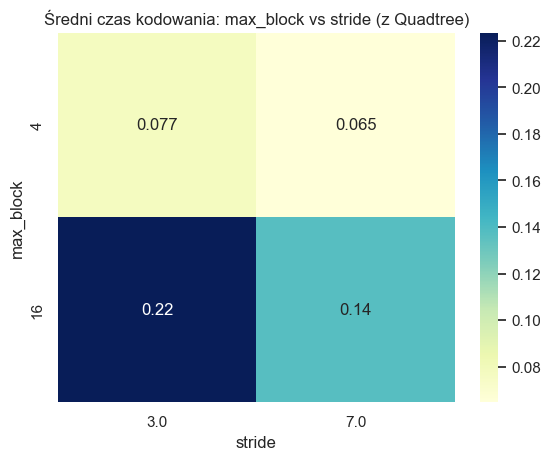

In [ ]:
# Przygotowanie danych - średni czas dla kombinacji blok/krok (filtrujemy dla Quadtree=True)
pivot_df = df[df["use_quadtree"] == True].pivot_table(
    values="ffc_mean_s", index="max_block", columns="stride"
)

sns.heatmap(pivot_df, annot=True, cmap="YlGnBu")
plt.title("Średni czas kodowania: max_block vs stride (z Quadtree)")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


def visualize_benchmark_results(df, features, mode="both"):
    """
    Wizualizuje wyniki benchmarków dla listy wybranych cech.
    Dodaje linię odniesienia dla kompresji JPEG na wykresie współczynnika.

    Argumenty:
    - df: DataFrame z wynikami (musi zawierać ffc_mean_s, ffc_ratio, jpeg_compression_ratio).
    - features: lista cech do analizy na osi X (np. ['max_block', 'stride']).
    - mode: 'time' (tylko czas), 'ratio' (tylko kompresja), 'both' (oba).
    """
    sns.set_theme(style="whitegrid")

    # Pobranie wartości JPEG (zakładamy stałą jakość w teście, np. 90)
    jpeg_ratio_val = None
    if "jpeg_compression_ratio" in df.columns:
        jpeg_ratio_val = df["jpeg_compression_ratio"].mean()

    for feature in features:
        if feature not in df.columns:
            print(f"Ostrzeżenie: Cecha '{feature}' nie została znaleziona w danych.")
            continue

        plot_df = df.sort_values(by=feature)

        # 1. Wykres czasu (Słupkowy)
        if mode in ["time", "both"]:
            plt.figure(figsize=(10, 5))
            sns.barplot(
                data=plot_df,
                x=feature,
                y="ffc_mean_s",
                color="skyblue",
                edgecolor="black",
            )
            plt.title(f"Wpływ {feature} na średni czas kompresji")
            plt.ylabel("Średni czas [s]")
            plt.xlabel(feature)
            plt.tight_layout()
            plt.show()

        # 2. Wykres współczynnika kompresji (Liniowy)
        if mode in ["ratio", "both"]:
            plt.figure(figsize=(10, 5))
            sns.lineplot(
                data=plot_df,
                x=feature,
                y="ffc_compression_ratio",
                marker="o",
                color="coral",
                linewidth=2,
                label="FFC (Fraktalna)",
            )

            # Dodanie poziomej linii JPEG
            if jpeg_ratio_val is not None:
                plt.axhline(
                    y=jpeg_ratio_val,
                    color="red",
                    linestyle="--",
                    linewidth=1.5,
                    label=f"JPEG Baseline ({jpeg_ratio_val:.2f})",
                )

            # Skala logarytmiczna dla czytelności dużych różnic
            if (
                plot_df["ffc_compression_ratio"].max()
                / (plot_df["ffc_compression_ratio"].min() + 1e-6)
                > 10
            ):
                plt.yscale("log")
                plt.ylabel("Stopień kompresji (log)")
            else:
                plt.ylabel("Stopień kompresji")

            plt.title(f"Wpływ {feature} na stopień kompresji")
            plt.xlabel(feature)
            plt.legend()  # Wyświetla etykiety FFC i JPEG
            plt.tight_layout()
            plt.show()

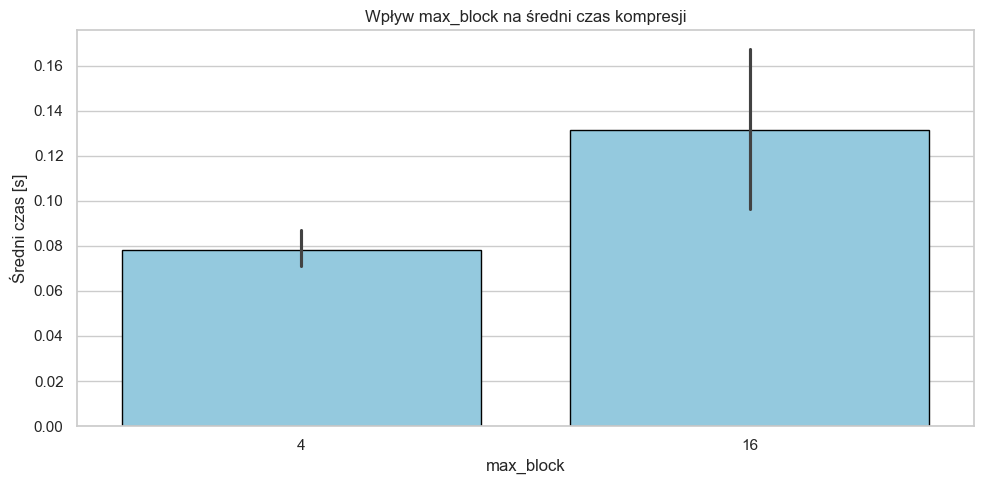

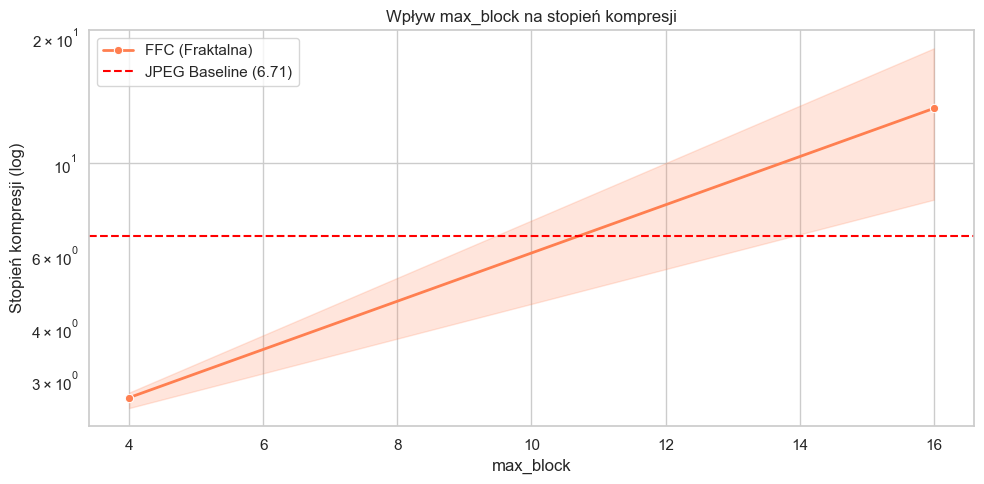

In [ ]:
visualize_benchmark_results(df, features=["max_block"], mode="both")